In [10]:
import csv
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('../Fonts/Times New Roman.ttf')
fm.fontManager.addfont('../Fonts/SimSun.ttf')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun', 'DejaVu Serif']
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.size'] = 12

In [11]:
with open('../build/log.xlsx', 'r', newline='') as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    headers = reader.fieldnames or []

print(headers)

cols = {name: [float(r[name]) for r in rows] for name in headers}

['t', 'ud_ref', 'uq_ref', 'ua', 'ub', 'uc', 'v_dc', 'duty_a', 'duty_b', 'duty_c', 'gate_u_a', 'gate_l_a', 'gate_u_b', 'gate_l_b', 'gate_u_c', 'gate_l_c', 'i_frontend', 'i_batt', 'omega_mech', 'theta_mech', 'theta_e', 'ia', 'ib', 'ic', 'id', 'iq', 'T_em', 'T_turb', 'T_pump', 'p_plenum', 'p_downstream_turb', 'm_dot_in', 'm_dot_turb', 'm_dot_out', 'p_discharge', 'Q_pump', 'Q_out']


In [12]:
t = cols['t']
ua = cols['ua']
ub = cols['ub']
uc = cols['uc']

omega_mech = cols['omega_mech']
omega_rpm = [w * 60.0 / (2.0 * 3.141592653589793) for w in omega_mech]
theta_mech = cols['theta_mech']
theta_e = cols['theta_e']

ia = cols['ia']
ib = cols['ib']
ic = cols['ic']
id_curr = cols['id']
iq = cols['iq']

T_em = cols['T_em']
T_turb = cols['T_turb']
T_pump = cols['T_pump']
T_net = [te + tt - tp for te, tt, tp in zip(T_em, T_turb, T_pump)]

p_plenum = cols.get('p_plenum', [])
p_downstream_turb = cols.get('p_downstream_turb', [])

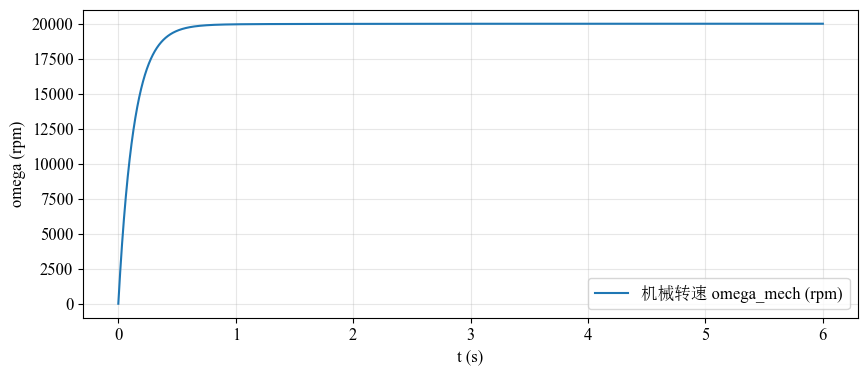

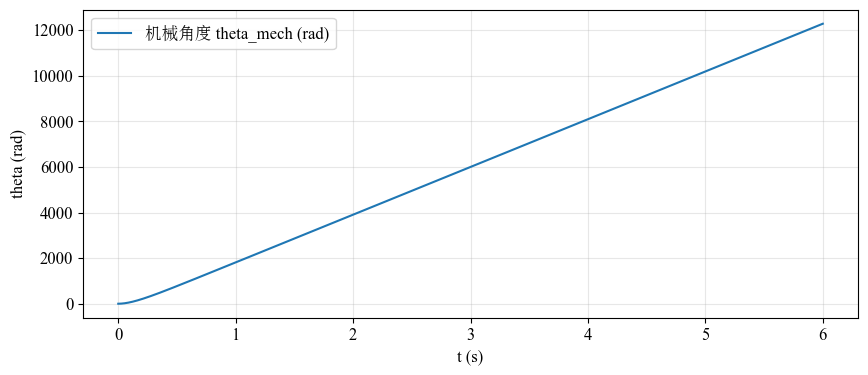

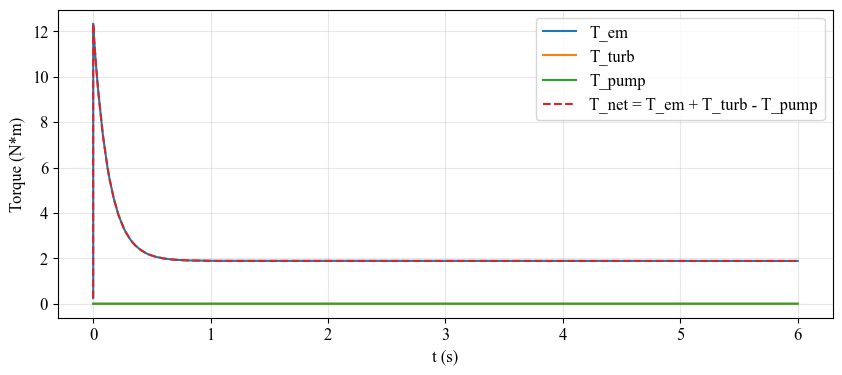

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(t, omega_rpm, label='机械转速 omega_mech (rpm)')
plt.xlabel('t (s)')
plt.ylabel('omega (rpm)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.figure(figsize=(10, 4))
plt.plot(t, theta_mech, label='机械角度 theta_mech (rad)')
plt.xlabel('t (s)')
plt.ylabel('theta (rad)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.figure(figsize=(10, 4))
plt.plot(t, T_em, label='T_em')
plt.plot(t, T_turb, label='T_turb')
plt.plot(t, T_pump, label='T_pump')
plt.plot(t, T_net, '--', label='T_net = T_em + T_turb - T_pump')
plt.xlabel('t (s)')
plt.ylabel('Torque (N*m)')
plt.grid(True, alpha=0.3)
plt.legend()

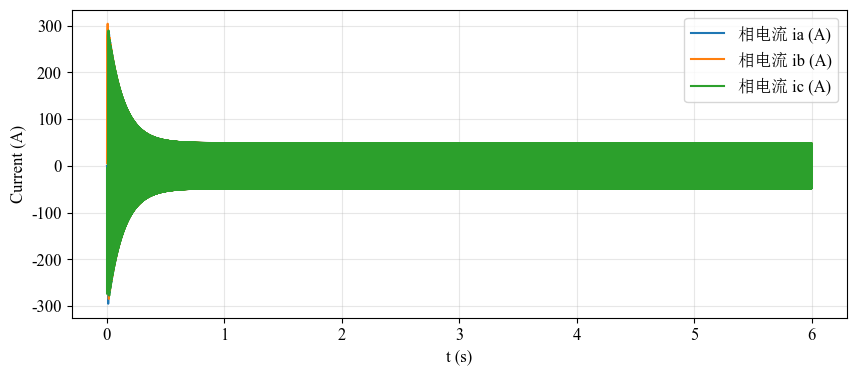

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(t, ia, label='相电流 ia (A)')
plt.plot(t, ib, label='相电流 ib (A)')
plt.plot(t, ic, label='相电流 ic (A)')
plt.xlabel('t (s)')
plt.ylabel('Current (A)')
plt.grid(True, alpha=0.3)
plt.legend()

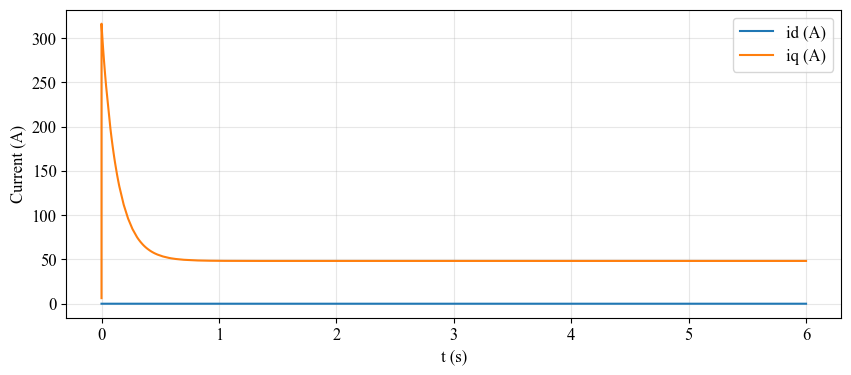

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(t, id_curr, label='id (A)')
plt.plot(t, iq, label='iq (A)')
plt.xlabel('t (s)')
plt.ylabel('Current (A)')
plt.grid(True, alpha=0.3)
plt.legend()

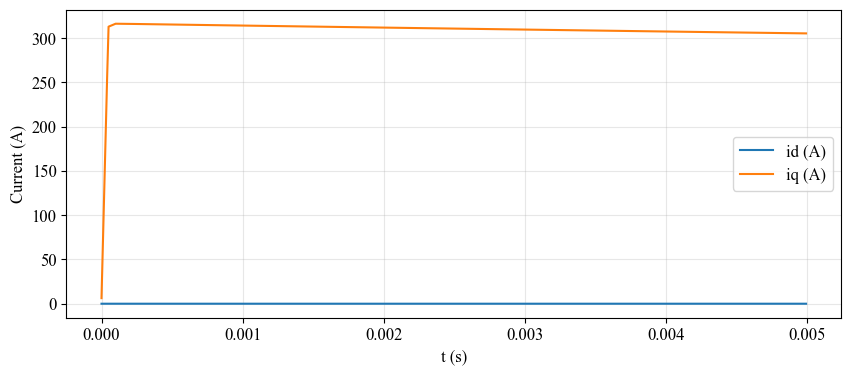

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(t[:500], id_curr[:500], label='id (A)')
plt.plot(t[:500], iq[:500], label='iq (A)')
plt.xlabel('t (s)')
plt.ylabel('Current (A)')
plt.grid(True, alpha=0.3)
plt.legend()

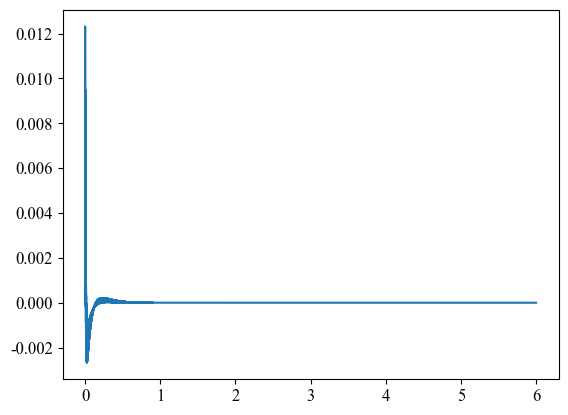

In [17]:
plt.plot(t, id_curr, label='id (A)')

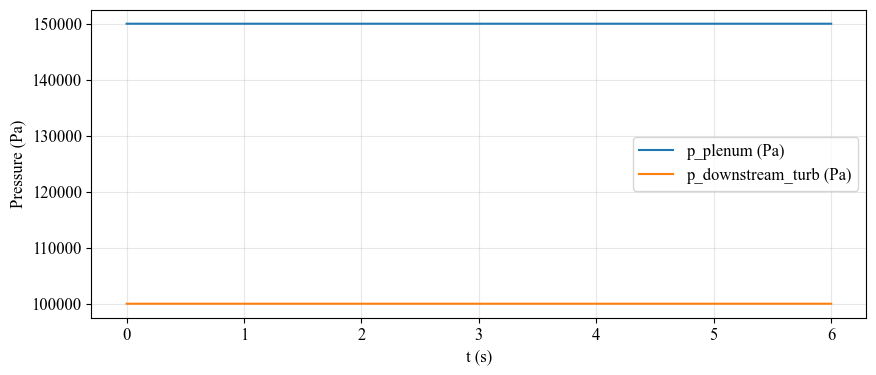

In [18]:
if p_plenum and p_downstream_turb:
    plt.figure(figsize=(10, 4))
    plt.plot(t, p_plenum, label='p_plenum (Pa)')
    plt.plot(t, p_downstream_turb, label='p_downstream_turb (Pa)')
    plt.xlabel('t (s)')
    plt.ylabel('Pressure (Pa)')
    plt.grid(True, alpha=0.3)
    plt.legend()